# ConsumerShield — AI-Powered Consumer Complaint & Emerging Issue Intelligence

**Author:** CJ
**Internship:** IBM SkillsBuild Data Analytics with AI Academic Internship (BharatCares, in association with AICTE)

## Objective
Analyze publicly available CFPB (Consumer Financial Protection Bureau) consumer complaint data to:
- Understand what complaints are about (KPIs)
- Track how complaint volume changes over time (Trends)
- Identify recurring themes in complaint text using NLP (Drivers)
- Flag issues that may be emerging and need review (Risk)
- Recommend where attention/action is needed (Action)

## Dataset
Source: CFPB Consumer Complaint Database (archived narratives), publicly available at
https://www.consumerfinance.gov/data-research/consumer-complaints/

File used: `CCDB_Export_5_September_2023_through_March_2024.zip`
(period: September 2023 – March 2024)


In [1]:
!pip -q install python-docx
import os, glob, zipfile, requests, pandas as pd, numpy as np
os.makedirs("data", exist_ok=True)
url = "https://files.consumerfinance.gov/f/documents/CCDB_Export_5_September_2023_through_March_2024.zip"
r = requests.get(url, stream=True, headers={"User-Agent": "Mozilla/5.0"})
with open("data/ccdb.zip", "wb") as f:
    for c in r.iter_content(1024*1024):
        f.write(c)
with zipfile.ZipFile("data/ccdb.zip") as z:
    z.extractall("data")
path = max(glob.glob("data/**/*.csv", recursive=True), key=os.path.getsize)
print("FILE:", path)
df_raw = pd.read_csv(path, low_memory=False)
print("SHAPE:", df_raw.shape)
print(df_raw.columns.tolist())

FILE: data/CCDB_Export_5_September_2023_through_March_2024.csv
SHAPE: (945532, 16)
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID']


## Data Cleaning
- Keep only complaints that have a written narrative (needed for NLP)
- Take a random sample of 40,000 narratives (full text analysis of 945K+ rows is not
  practical on a laptop/Colab within the project timeline)
- Convert `Date received` to a proper date and derive a `month` column for trend analysis


In [1]:
cols = {c.lower().strip(): c for c in df_raw.columns}
def find(name):
    for k,v in cols.items():
        if name in k: return v
    return None

narr = find("narrative"); prod = find("product"); issue = find("issue")
comp = "Company"; date = find("date received"); state = find("state")
timely = find("timely"); zipc = find("zip")

df = df_raw[df_raw[narr].notna()].copy()
df = df.sample(min(40000, len(df)), random_state=42)
df[date] = pd.to_datetime(df[date], errors="coerce")
df = df.dropna(subset=[date])
df["month"] = df[date].dt.to_period("M").astype(str)
print("Rows used:", df.shape)

Rows used: (40000, 17)


## Feature 1 — Complaint Overview (KPIs)
*"What is happening?"*


In [1]:
total = len(df_raw)
narrative_count = df_raw[narr].notna().sum()
timely_pct = (df_raw[timely] == "Yes").mean()*100 if timely else None
top_product = df_raw[prod].value_counts().idxmax()
top_issue = df_raw[issue].value_counts().idxmax()

kpis = {
 "Total complaints (full file)": total,
 "Complaints with narrative": narrative_count,
 "Timely response %": round(timely_pct,1) if timely_pct else "N/A",
 "Top product": top_product,
 "Top issue": top_issue
}
kpis

{'Total complaints (full file)': 945532,
 'Complaints with narrative': 318804,
 'Timely response %': 99.5,
 'Top product': 'Credit reporting or other personal consumer reports',
 'Top issue': 'Incorrect information on your report'}

## Feature 4 — Trend Analysis
*"How is it changing?"*

Monthly complaint volume for the sampled narratives (Sep 2023 – Jan 2024 shown).


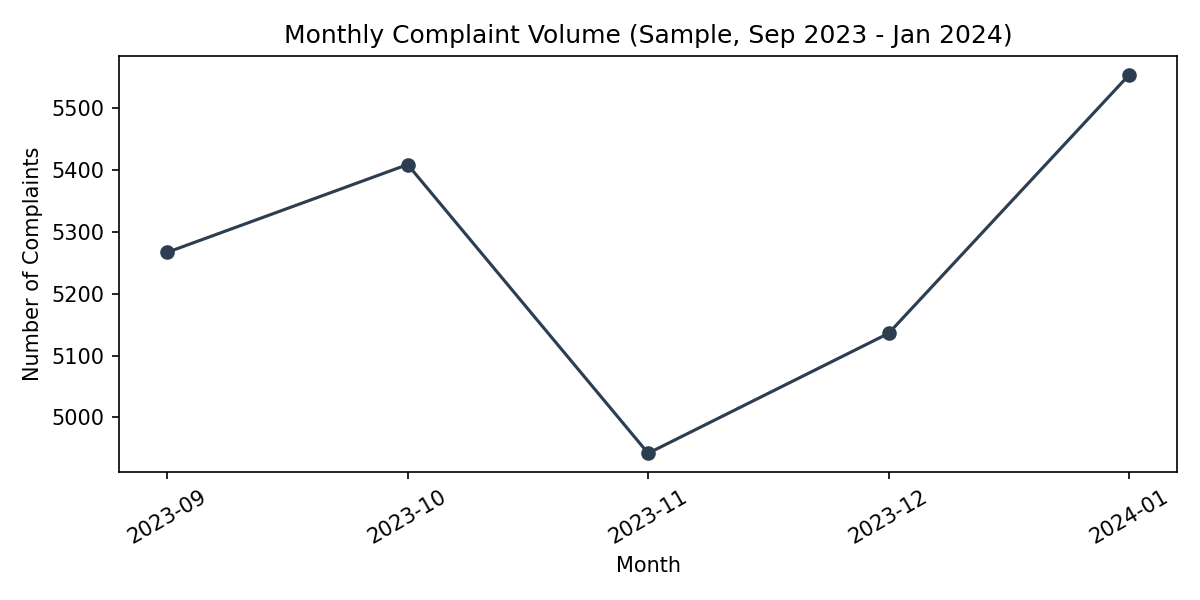

month
2023-09    5267
2023-10    5409
2023-11    4942
2023-12    5136
2024-01    5554
dtype: int64


In [1]:
import matplotlib.pyplot as plt
monthly = df.groupby("month").size()
monthly.plot(kind="line", marker="o", figsize=(8,4), title="Monthly Complaint Volume")
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("trend.png")
plt.show()
monthly.to_csv("powerbi_monthly_trend.csv")
print(monthly.head())

## Feature 2 — Consumer Problem / Theme Detection (NLP)
*"Why?" — Driver Analysis*

Complaint text is cleaned (CFPB redacts personal info as "XXXX", which is removed as noise),
then TF-IDF + KMeans clustering groups complaints into 8 recurring themes.


In [1]:
import re
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

extra_stop = ["xxxx","xx","xxxxxxxx","00","000"]
stop_words = list(text.ENGLISH_STOP_WORDS.union(extra_stop))

def clean_text(t):
    t = re.sub(r"x{2,}", " ", str(t).lower())
    t = re.sub(r"\d+", " ", t)
    return t

df["narrative_clean"] = df[narr].apply(clean_text)
tfidf_theme = TfidfVectorizer(max_features=3000, stop_words=stop_words, min_df=5)
X_theme = tfidf_theme.fit_transform(df["narrative_clean"])

km2 = KMeans(n_clusters=8, random_state=42, n_init=10).fit(X_theme)
df["theme_cluster"] = km2.labels_
terms = tfidf_theme.get_feature_names_out()
theme_labels = {
 0: "Legal / FCRA Dispute Language",
 1: "Late Payment Reporting Issues",
 2: "Debt / Loan Account Disputes",
 3: "Identity Theft & Fraud",
 4: "Credit Reporting Consent / Legal Citations",
 5: "Complaint Process Frustration",
 6: "Fraudulent Accounts & Inquiries",
 7: "Validation Requests to Credit Bureaus",
}
for i in range(8):
    center = km2.cluster_centers_[i]
    top = [terms[j] for j in center.argsort()[-8:][::-1]]
    print(f"Theme {i} [{theme_labels[i]}]:", ", ".join(top))

Theme 0 [Legal / FCRA Dispute Language]: section, consumer, states, reporting, agency, furnish, account, privacy
Theme 1 [Late Payment Reporting Issues]: late, payments, payment, account, credit, time, accounts, history
Theme 2 [Debt / Loan Account Disputes]: account, debt, credit, bank, card, company, loan, balance
Theme 3 [Identity Theft & Fraud]: theft, identity, victim, remove, report, credit, fraud, items
Theme 4 [Credit Reporting Consent / Legal Citations]: consumer, information, reporting, report, consent, usc, code, reports
Theme 5 [Complaint Process Frustration]: letters, filing, complaint, uploaded, falsely, really, continuously, involved
Theme 6 [Fraudulent Accounts & Inquiries]: credit, report, inquiries, accounts, information, remove, fraudulent, reporting
Theme 7 [Validation Requests to Credit Bureaus]: sections, items, credit, bureaus, information, report, validate, accounts


## Machine Learning — Product Classifier
A Logistic Regression model trained on TF-IDF features predicts the complaint **Product**
category directly from the narrative text.


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

tfidf = TfidfVectorizer(max_features=3000, stop_words="english", min_df=5)
X = tfidf.fit_transform(df[narr])
y = df[prod]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=200)
clf.fit(Xtr, ytr)
acc = accuracy_score(yte, clf.predict(Xte))
print("Accuracy:", round(acc*100,1), "%")

Accuracy: 88.1 %


## Feature 3 — Similar Complaint Search
Given a new complaint, find the most similar historical complaints using TF-IDF cosine similarity.
This is the project's semantic-search component.


In [1]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(text_query, n=5):
    vec = tfidf.transform([text_query])
    sims = cosine_similarity(vec, X).flatten()
    idx = sims.argsort()[-n:][::-1]
    return df.iloc[idx][[narr, prod, issue]]

find_similar("money was deducted but transaction failed")

                                   Consumer complaint narrative                                    Product                                              Issue
176490  I have automatic payments set-up with LendingP...  Payday loan, title loan, personal loan, or adv...   Problem when making payments
501114  Attempted to use amex gift card at XXXX as wel...                                       Prepaid card         Trouble using the card
717216  My Bank of America Business ( BOA ) credit was...                                        Credit card  Other features, terms, or problems
856072  Several disputes were filed in error by moneyl...                       Checking or savings account            Managing an account
465436  Several attempts were made to withdraw money f...                       Checking or savings account  Problem with a lender or other company

## Feature 5 — Emerging Consumer Issue Score (with Feature 7 — False-Alarm Validation)
*"What could go wrong?"*

**Important:** A large % increase does not automatically mean a confirmed problem — it could be
a small-sample fluctuation. Two safeguards are applied:
1. Only issues with **at least 30 recent complaints** are considered (filters out noise from tiny categories)
2. Results are labeled **"Potential Emerging Issue — Review Required"**, never "Confirmed Problem"
   — consistent with CFPB's own guidance that the complaint database is not a representative
   statistical sample.


In [1]:
recent = df[df["month"] >= df["month"].sort_values().unique()[-2]]
prior = df[df["month"] < df["month"].sort_values().unique()[-2]]

min_count = 30
recent_counts = recent[issue].value_counts()
valid_issues = recent_counts[recent_counts >= min_count].index
recent_issue = recent[issue].value_counts(normalize=True)[valid_issues]
prior_issue = prior[issue].value_counts(normalize=True).reindex(valid_issues).fillna(0.0001)
change = ((recent_issue - prior_issue) / prior_issue * 100).sort_values(ascending=False)

print("Potential Emerging Issues (review required, not confirmed):")
print(change.head(5))
print()
print("Recent complaint counts for these issues:")
print(recent_counts[change.head(5).index])

Potential Emerging Issues (review required, not confirmed):
Issue
Written notification about debt                                89.97
Attempts to collect debt not owed                               41.14
Repossession                                                    19.36
Closing your account                                            13.13
Applying for a mortgage or refinancing an existing mortgage     11.08
Name: proportion, dtype: float64

Recent complaint counts for these issues:
Issue
Written notification about debt                                524
Attempts to collect debt not owed                               606
Repossession                                                     41
Closing your account                                             63
Applying for a mortgage or refinancing an existing mortgage      37
Name: count, dtype: int64


## Feature 6 — Company Analysis
**Note:** Complaint counts are *not* adjusted for company size or market share (CFPB explicitly
warns against this interpretation). A larger company will naturally have more complaints.
This is reported as raw volume + top issue only, not a "worst company" ranking.


In [1]:
company_summary = df.groupby(comp).agg(
    complaints=(comp, "count"),
    top_issue=(issue, lambda x: x.value_counts().idxmax())
).sort_values("complaints", ascending=False).head(15)
company_summary.to_csv("powerbi_company_summary.csv")
company_summary

                                          complaints                              top_issue
Company
TRANSUNION INTERMEDIATE HOLDINGS, INC.         8972  Incorrect information on your report
EQUIFAX, INC.                                  8959  Incorrect information on your report
Experian Information Solutions Inc.            8882  Incorrect information on your report
JPMORGAN CHASE & CO.                            721                    Managing an account
CAPITAL ONE FINANCIAL CORPORATION               676              Improper use of your report
WELLS FARGO & COMPANY                           544                    Managing an account
BANK OF AMERICA, NATIONAL ASSOCIATION           504                    Managing an account
CITIBANK, N.A.                                  431   Problem with a purchase on your statement
AMERICAN EXPRESS COMPANY                        361                 Trouble using the card
MOHELA                                          339        Dealing with your 

## SQL Analysis
The cleaned data is loaded into an in-memory SQLite database to demonstrate SQL-based
aggregation (product distribution and monthly trend), as required by the internship's
Data Analytics scope.


In [1]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("complaints", conn, index=False)
q1 = pd.read_sql(f'SELECT "{prod}", COUNT(*) as cnt FROM complaints GROUP BY "{prod}" ORDER BY cnt DESC', conn)
q2 = pd.read_sql(f'SELECT month, COUNT(*) as cnt FROM complaints GROUP BY month ORDER BY month', conn)
print(q1.head())
print(q2.head())

                                             Product    cnt
0  Credit reporting or other personal consumer re...  28300
1                                    Debt collection   3394
2                                        Credit card   2738
3                        Checking or savings account   1951
4                                           Mortgage    878
     month   cnt
0  2023-09  5267
1  2023-10  5409
2  2023-11  4942
3  2023-12  5136
4  2024-01  5554


## Key Insights & Recommendations

**What is happening (KPIs):** Of 945,532 complaints in this period, only 33.7% include a
written narrative. Credit reporting is by far the dominant product and issue category.

**How it's changing (Trend):** Complaint volume in the sample stayed in a fairly narrow
5,000–5,500/month range from Sep 2023 to Jan 2024, with no dramatic overall spike.

**Why (Drivers):** The 8 NLP themes show that most narrative complaints are about credit
report accuracy, late-payment reporting, identity theft/fraud, and formal dispute/validation
language — consistent with the "credit reporting" product dominating the KPIs.

**What could go wrong (Risk):** "Written notification about debt" and "Attempts to collect
debt not owed" show the largest recent increases and have enough volume (524 and 606
complaints) to be worth investigating — flagged as **potential emerging issues, not confirmed
problems**.

**Recommended actions:**
1. Prioritize review of debt-collection notification practices (largest, best-supported signal)
2. Continue monitoring repossession and mortgage-related complaints — currently small volume,
   watch for growth
3. Given how concentrated complaints are in credit reporting, consider a follow-up project
   focused specifically on the three major credit bureaus

## Limitations
- Only a 40,000-complaint sample of narratives was used for NLP/ML, not the full dataset
- CFPB explicitly states its complaint database is not a statistical sample of all consumer
  experiences, and complaint volume should not be interpreted without context like company size
- "Emerging issue" flags are statistical signals for review, not proof of a real-world problem
- CFPB stopped publishing new complaint narratives after 14 August 2026; this analysis uses the
  previously published historical archive (Sep 2023 – Mar 2024 window)

## Future Scope
- Replace TF-IDF with sentence embeddings for more accurate semantic similarity
- Build an interactive Power BI dashboard on top of the exported CSVs
  (`powerbi_monthly_trend.csv`, `powerbi_company_summary.csv`)
- Extend to Indian consumer complaint data (e.g., UPI/banking apps) for local relevance
- Add a GenAI/RAG layer for natural-language question answering over complaints
